# ***MEDICAL INSURANCE***

The dataset used in this project, titled "Medical Insurance Charges (2021–2025) Enhanced", was obtained from Kaggle and published by Muhammad Ibrahim Shahrukh.

I chose this health insurance dataset to predict insurance charges and understand the factors affecting medical costs.

In [ ]:
#Imported essential libraries to make data manipulation and plotting easier.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

In [ ]:
#importing dataset
df = pd.read_csv("medical_insurance.csv")

# **BASIC INFO**

In [ ]:
df.head() #to see the first fIVE rows of the data

,record_date,year,quarter,age,age_group,sex,sex_female,bmi,bmi_category,children,...,region,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
0,2024-02-01,2024,1,19,Young Adult (18-25),female,1,27.90,Overweight,0,...,southwest,0,0,0,1,16884.92,1407.08,0.00,Platinum,530.10
1,2024-12-30,2024,4,18,Young Adult (18-25),male,0,33.77,Obese Class I,1,...,southeast,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86
2,2023-05-11,2023,2,28,Adult (26-35),male,0,33.00,Obese Class I,3,...,southeast,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00
3,2024-07-18,2024,3,33,Adult (26-35),male,0,22.70,Normal Weight,0,...,northwest,0,1,0,0,21984.47,1832.04,0.00,Diamond,749.10
4,2024-02-05,2024,1,32,Adult (26-35),male,0,28.88,Overweight,0,...,northwest,0,1,0,0,3866.86,322.24,0.00,Bronze,924.16


In [ ]:
df.info() #to check if there are any missing values or incorrect data types in the columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_date          1337 non-null   object 
 1   year                 1337 non-null   int64  
 2   quarter              1337 non-null   int64  
 3   age                  1337 non-null   int64  
 4   age_group            1337 non-null   object 
 5   sex                  1337 non-null   object 
 6   sex_female           1337 non-null   int64  
 7   bmi                  1337 non-null   float64
 8   bmi_category         1337 non-null   object 
 9   children             1337 non-null   int64  
 10  smoker               1337 non-null   object 
 11  smoker_flag          1337 non-null   int64  
 12  is_high_risk         1337 non-null   int64  
 13  risk_score           1337 non-null   float64
 14  region               1337 non-null   object 
 15  region_northeast     1337 non-null   i

In [ ]:
df.shape #checking total number of rows and columns in the dataset.

(1337, 24)

In [ ]:
df.isnull().sum() #Counting the exact number of empty (null) cells in every column

,0
record_date,0
year,0
quarter,0
age,0
age_group,0
sex,0
sex_female,0
bmi,0
bmi_category,0
children,0


In [ ]:
df.duplicated().sum() #checking if there any repeated rows exist

np.int64(0)

In [ ]:
df.dtypes # checking data types of all columns

,0
record_date,object
year,int64
quarter,int64
age,int64
age_group,object
sex,object
sex_female,int64
bmi,float64
bmi_category,object
children,int64


In [ ]:
df.columns #checking columns of the dataset

Index(['record_date', 'year', 'quarter', 'age', 'age_group', 'sex',
       'sex_female', 'bmi', 'bmi_category', 'children', 'smoker',
       'smoker_flag', 'is_high_risk', 'risk_score', 'region',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'charges', 'monthly_premium_est',
       'charges_per_child', 'insurance_tier', 'bmi_age_interaction'],
      dtype='object')

In [ ]:
df.nunique()

,0
record_date,932
year,5
quarter,4
age,47
age_group,5
sex,2
sex_female,2
bmi,528
bmi_category,6
children,6


In [ ]:
#Removing irrelevant and redundant columns to prevent noise and data leakage.
cols_to_drop = ['record_date', 'year', 'quarter', 'age_group', 'bmi_category', 'region', 'insurance_tier','sex', 'smoker']
df_final = df.drop(columns=cols_to_drop)

print("\n COLUMNS AFTER CLEANING:")
print(df_final.columns)


 COLUMNS AFTER CLEANING:
Index(['age', 'sex_female', 'bmi', 'children', 'smoker_flag', 'is_high_risk',
       'risk_score', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest', 'charges',
       'monthly_premium_est', 'charges_per_child', 'bmi_age_interaction'],
      dtype='object')


# **EDA AND VISUALIZATION OF DATASET**

Text(0, 0.5, 'Average charges')

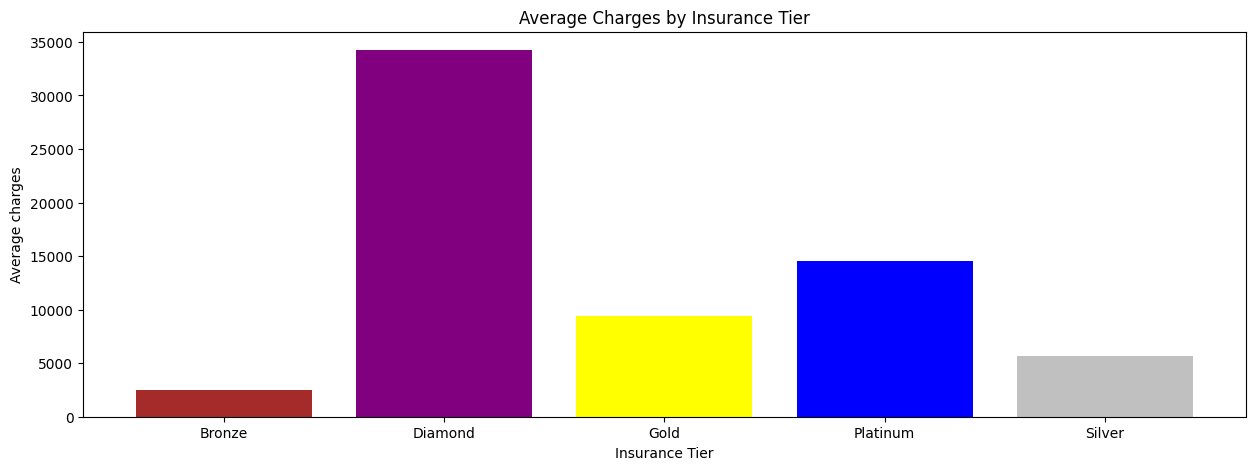

In [ ]:

tier_avrage = df.groupby("insurance_tier")["charges"].mean()
plt.figure(figsize=(15,5))
plt.bar(tier_avrage.index,tier_avrage.values,color = ["Brown","purple","yellow","blue","silver"])
plt.title("Average Charges by Insurance Tier")
plt.xlabel("Insurance Tier")
plt.ylabel("Average charges")

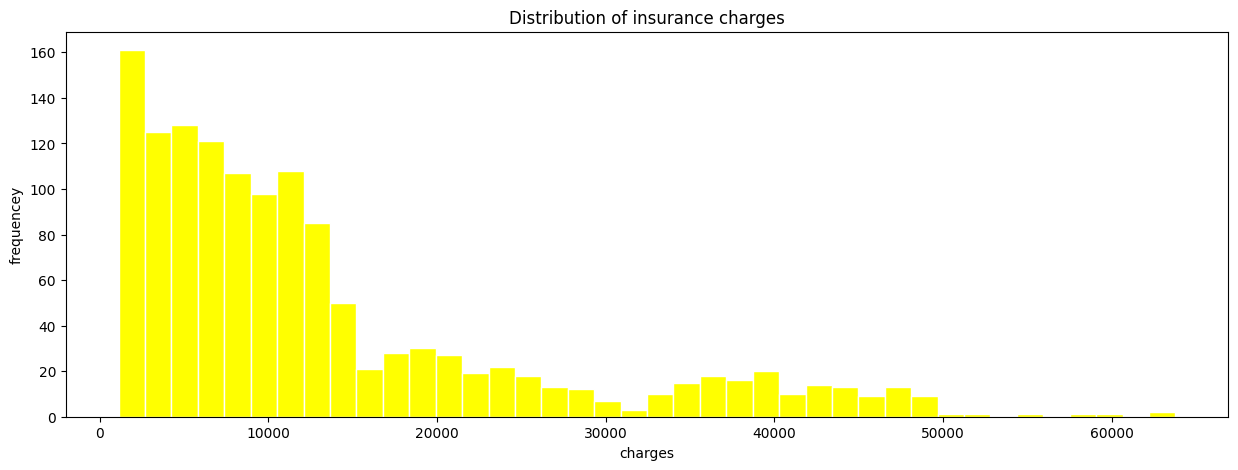

In [ ]:

plt.figure(figsize=(15,5))
plt.hist(df["charges"], bins =40, color= "yellow", edgecolor="white")
plt.title("Distribution of insurance charges")
plt.xlabel("charges")
plt.ylabel("frequencey")
plt.show()

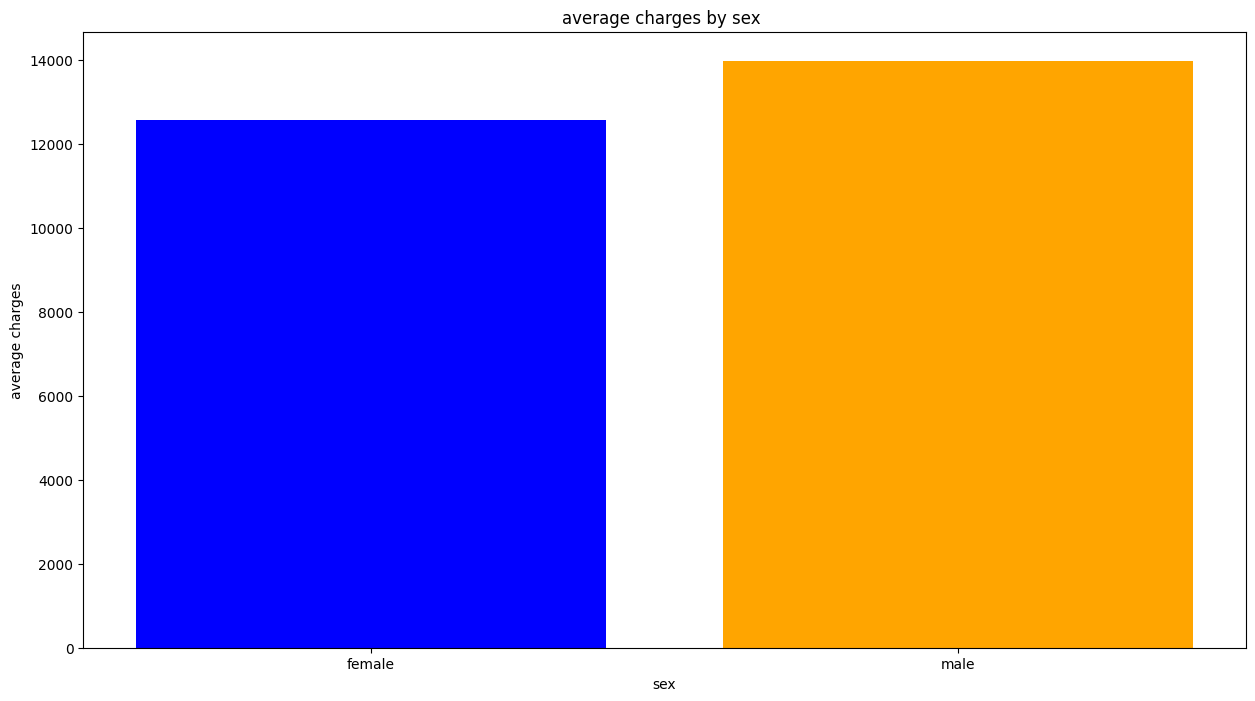

In [ ]:

avg_charges_sex = df.groupby("sex")["charges"].mean()
plt.figure(figsize=(15,8))
plt.bar(avg_charges_sex.index,avg_charges_sex.values,color=["blue","orange"])
plt.title("average charges by sex ")
plt.xlabel("sex")
plt.ylabel("average charges")
plt.show()

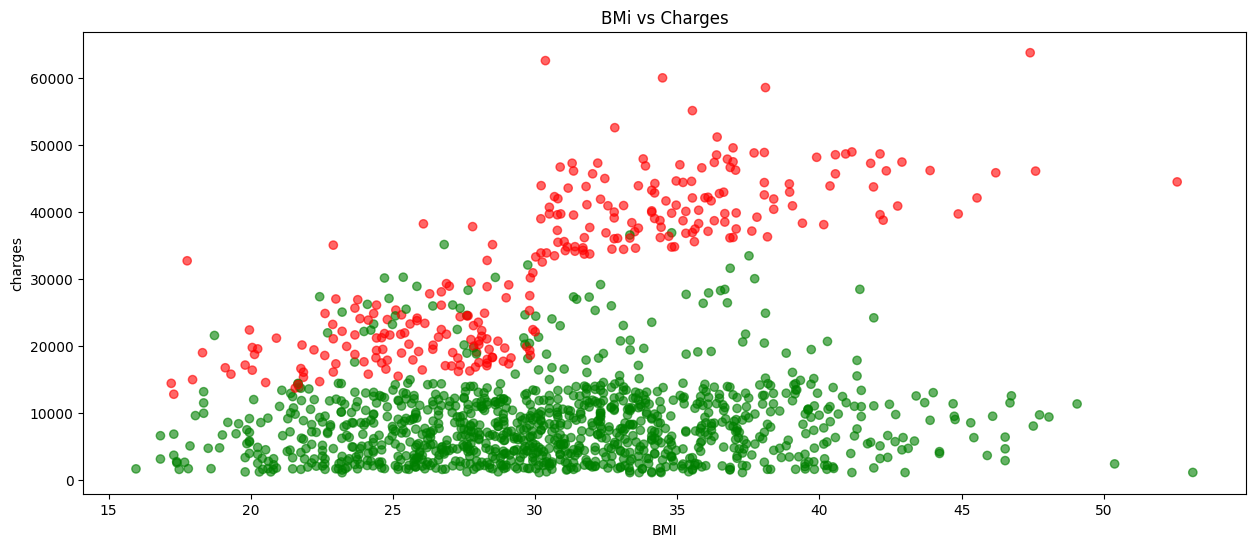

In [ ]:
colors = df["smoker_flag"].map({0: "green", 1: "red"})
plt.figure(figsize=(15,6))
plt.scatter(df["bmi"],df["charges"], c=colors, alpha=0.6)
plt.title("BMi vs Charges")
plt.xlabel("BMI")
plt.ylabel("charges")
plt.show()

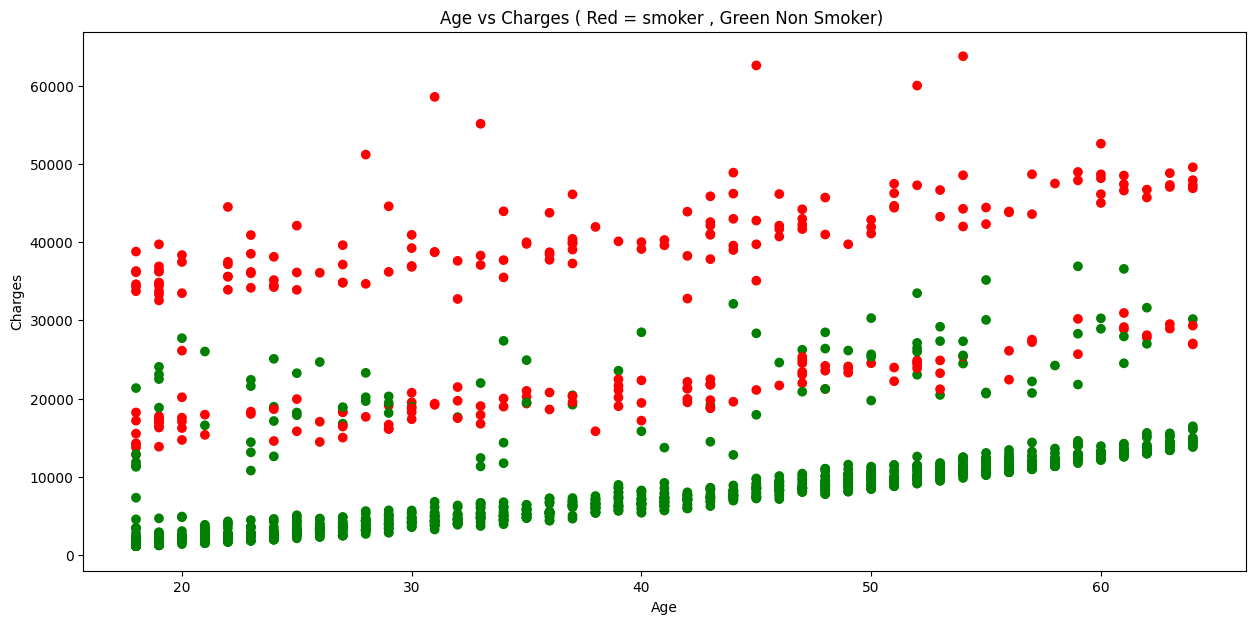

In [ ]:

colors = df["smoker_flag"].map({0: "green", 1: "red"})
plt.figure(figsize=(15,7))
plt.scatter(df["age"],df['charges'], c=colors)
plt.title("Age vs Charges ( Red = smoker , Green Non Smoker) ")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

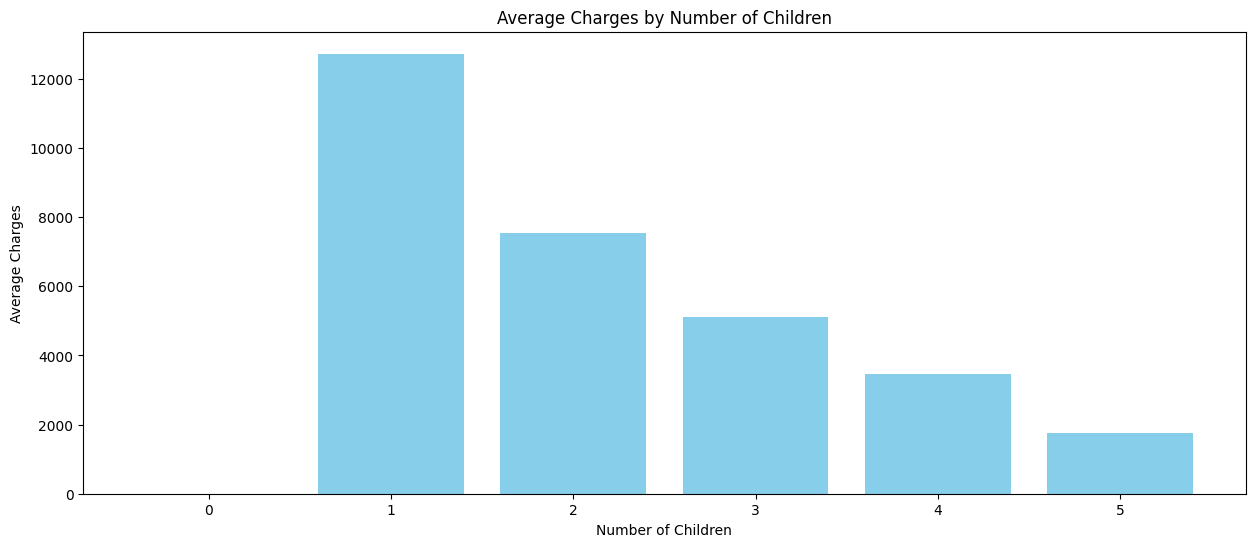

In [ ]:

children_avg = df.groupby('children')['charges_per_child'].mean()
plt.figure(figsize=(15,6))
plt.bar(children_avg.index, children_avg.values, color='skyblue')
plt.title('Average Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Average Charges')
plt.show()

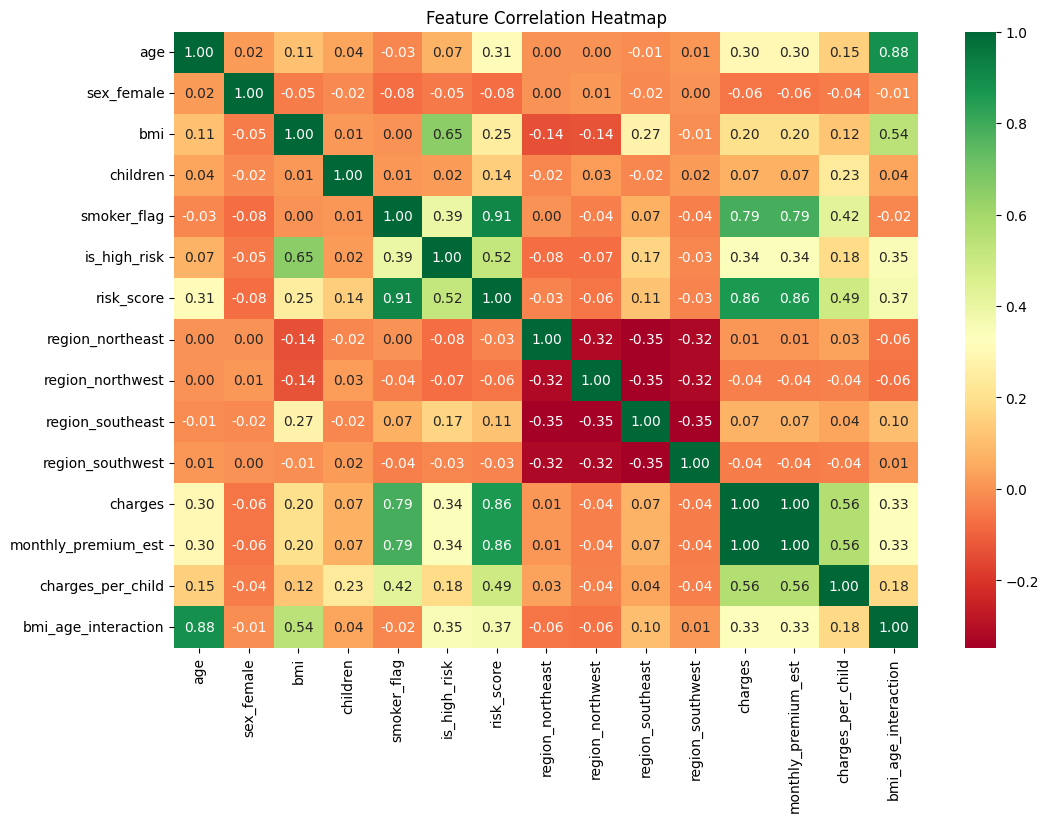

In [ ]:

plt.figure(figsize=(12, 8))
correlation_matrix = df_final.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

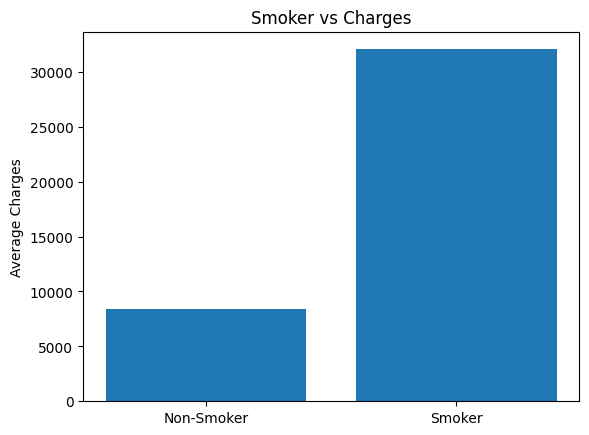

In [ ]:

smoker_avg = df.groupby("smoker_flag")["charges"].mean()
plt.bar(["Non-Smoker", "Smoker"], smoker_avg.values)
plt.title("Smoker vs Charges")
plt.ylabel("Average Charges")
plt.show()

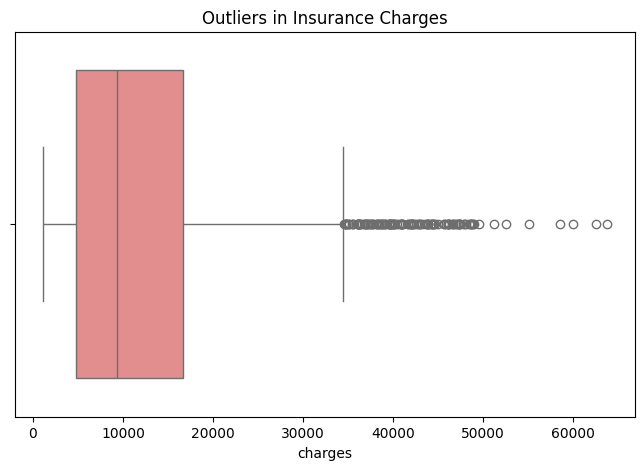

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_final['charges'], color='lightcoral')
plt.title('Outliers in Insurance Charges')
plt.show()

# **TRAIN-TEST-SPLIT**

In [ ]:
X = df_final.drop(columns=['charges', 'monthly_premium_est', 'risk_score', 'charges_per_child', 'is_high_risk'])
y = df_final['charges']

# 2. Train-Test Split (80% for Training, 20% for Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. checking test and split data size
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (1069, 10)
Testing set size: (268, 10)


# ***MODELS(WITH EDA)***

# **01) LINEAR REGRESSION**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

lr_predictions =model.predict(X_test)

mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_predictions)

print("--- Linear Regression Final Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score (Accuracy): {r2:.4f}")

--- Linear Regression Final Results ---
Mean Absolute Error (MAE): 4176.89
Root Mean Squared Error (RMSE): 5956.50
R2 Score (Accuracy): 0.8069



 Predictions vs Actual:
     Actual     Predicted
0   8688.86   8151.422129
1   5708.87   5735.076362
2  11436.74  14363.791653
3  38746.36  31746.515861
4   4463.21   8965.519538


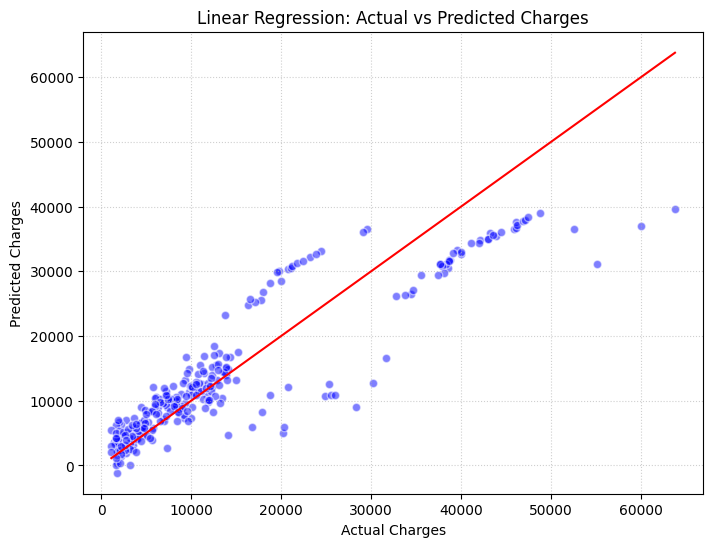

In [ ]:
comparison = pd.DataFrame({'Actual': y_test.values[:5], 'Predicted': lr_predictions[:5]})
print("\n Predictions vs Actual:")
print(comparison)

#SCATTER PLOT OF ACTUAL VS PREDICTED VALUES
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_predictions, color='blue', alpha=0.5, edgecolor='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')

plt.grid(True, linestyle=':', alpha=0.6)
plt.title('Linear Regression: Actual vs Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.show()

# ***02) DECISION TREE***

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("--- Decision Tree Results ---")
print(f"MAE: {mean_absolute_error(y_test, dt_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, dt_pred)):.2f}")
print(f"R2 Score: {r2_score(y_test, dt_pred):.4f}")

--- Decision Tree Results ---
MAE: 2916.46
RMSE: 6325.18
R2 Score: 0.7823


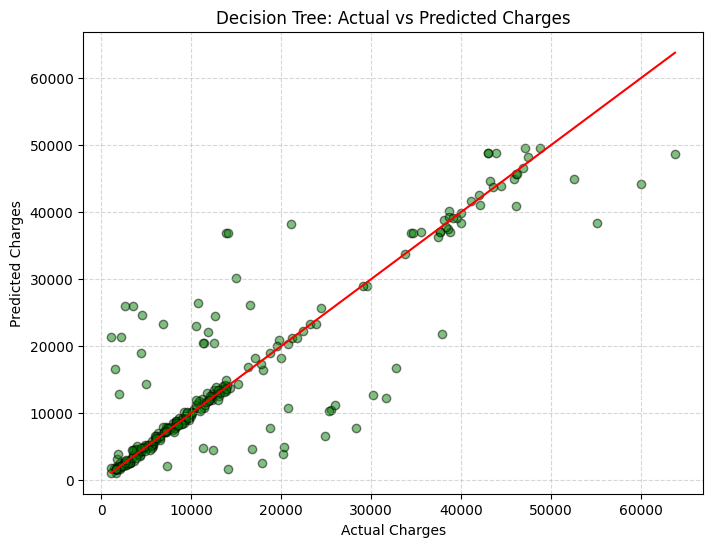

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dt_pred, color='green', alpha=0.5, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')

plt.title('Decision Tree: Actual vs Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ***03) KNN***

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

print("--- KNN Results ---")
print(f"MAE: {mean_absolute_error(y_test, knn_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, knn_pred)):.2f}")
print(f"R2 Score: {r2_score(y_test, knn_pred):.4f}")

--- KNN Results ---
MAE: 3447.14
RMSE: 5524.96
R2 Score: 0.8339


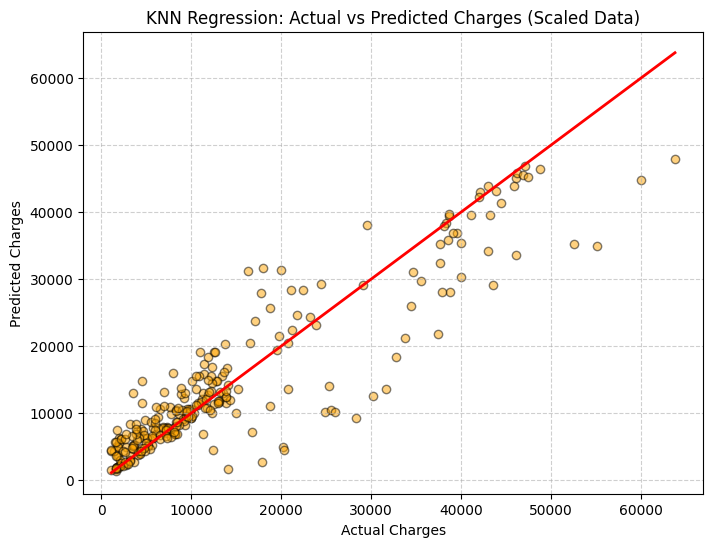

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, knn_pred, color='orange', alpha=0.5, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

plt.title('KNN Regression: Actual vs Predicted Charges (Scaled Data)')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# 1. Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. KNN Model with Scaling
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 3. Predictions
knn_pred = knn_model.predict(X_test_scaled)

# 4. Accuracy Check
knn_r2 = r2_score(y_test, knn_pred)
print(f"KNN Accuracy after Scaling: {knn_r2:.4f}")

# ***04) RANDOM FOREST***

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("--- Random Forest Results ---")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R2 Score (Accuracy): {rf_r2:.4f}")

--- Random Forest Results ---
MAE: 2541.22
RMSE: 4611.45
R2 Score (Accuracy): 0.8843



 Predictions Actual vs Predict:
     Actual  RF_Predicted
0   8688.86     9920.7592
1   5708.87     6577.2548
2  11436.74    11673.3630
3  38746.36    41373.4195
4   4463.21     5258.5804


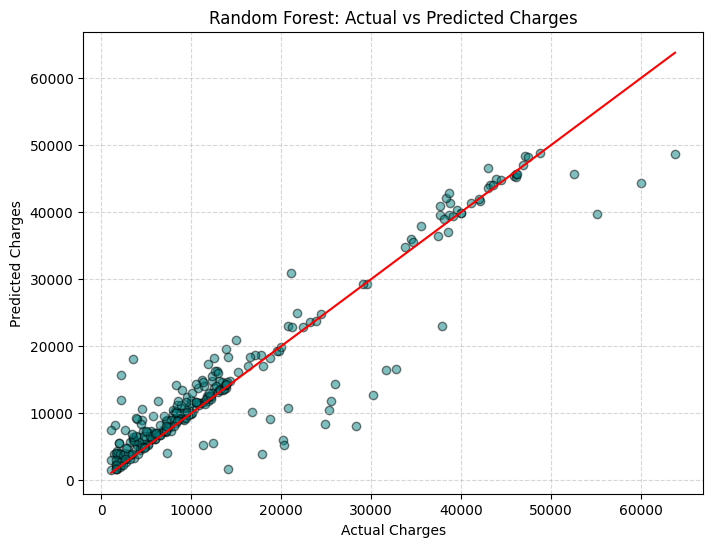

In [ ]:
rf_comparison = pd.DataFrame({'Actual': y_test.values[:5], 'RF_Predicted': rf_predictions[:5]})
print("\n Predictions Actual vs Predict:")
print(rf_comparison)

# Scatter Plot of Actual vs Predicted Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, color='teal', alpha=0.5, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')

plt.title('Random Forest: Actual vs Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

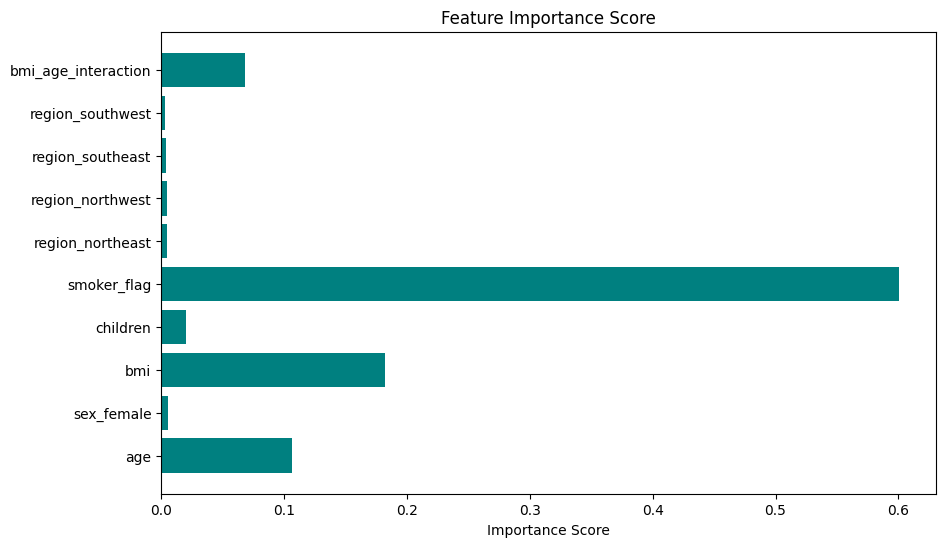

In [ ]:
importances = rf_model.feature_importances_
features = X_train.columns
plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='teal')
plt.xlabel('Importance Score')
plt.title('Feature Importance Score')
plt.show()

# ***05) RIDGE REGRESSION***

In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("--- Ridge Regression Results ---")
print(f"MAE: {mean_absolute_error(y_test, ridge_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ridge_pred)):.2f}")
print(f"R2 Score: {r2_score(y_test, ridge_pred):.4f}")

--- Ridge Regression Results ---
MAE: 4193.73
RMSE: 5971.37
R2 Score: 0.8060


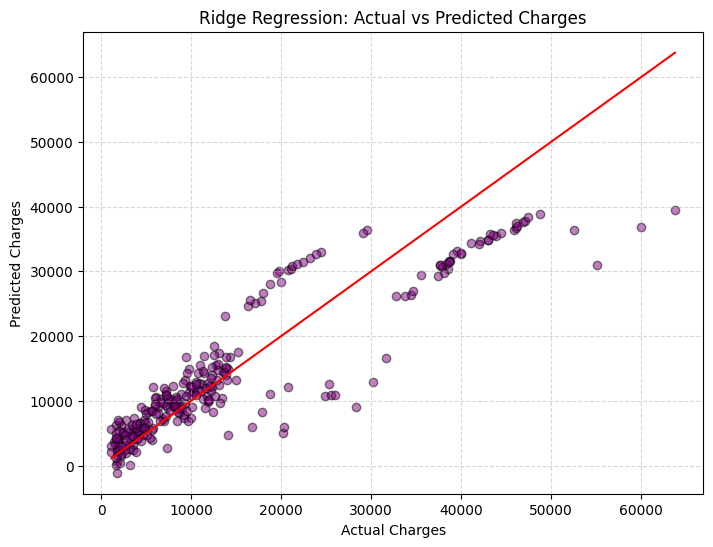

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, ridge_pred, color='purple', alpha=0.5, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')

plt.title('Ridge Regression: Actual vs Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# **FINAL COMPARISON BETWEEN ALL MODELS**

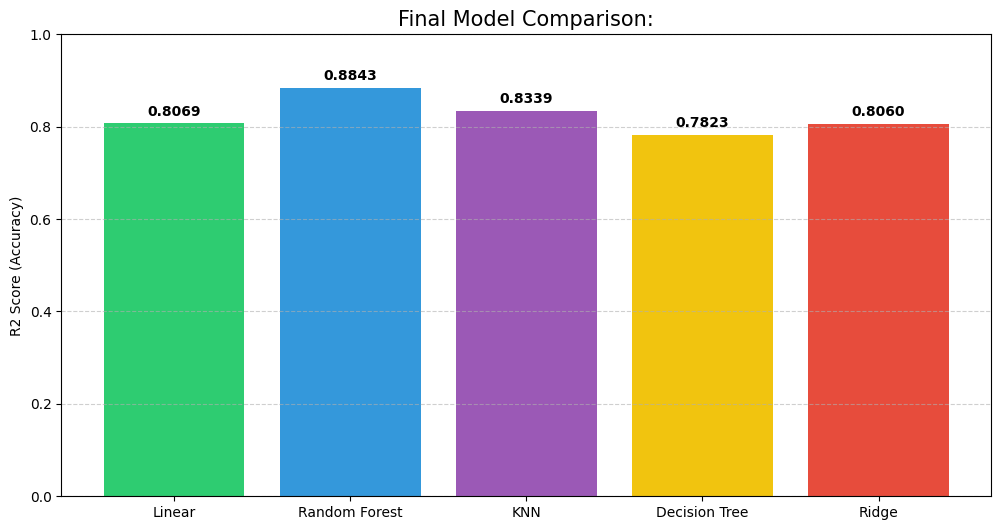

In [ ]:
model_names = ['Linear', 'Random Forest', 'KNN', 'Decision Tree', 'Ridge']
r2_scores = [0.8069, 0.8843,0.8339, 0.7823, 0.8060]

plt.figure(figsize=(12, 6))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f1c40f', '#e74c3c']
bars = plt.bar(model_names, r2_scores, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Final Model Comparison:', fontsize=15)
plt.ylabel('R2 Score (Accuracy)')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
final_results = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression', 'Ridge Regression', 'Decision Tree', 'KNN'],
    'R2 Score': [0.8843, 0.8069, 0.8060, 0.7823, 0.8339],
    'Accuracy': ['88.4%', '80.7%', '80.6%', '78.2%', '83.4%']
})
display(final_results)

,Model,R2 Score,Accuracy
0,Random Forest,0.8843,88.4%
1,Linear Regression,0.8069,80.7%
2,Ridge Regression,0.8060,80.6%
3,Decision Tree,0.7823,78.2%
4,KNN,0.8339,83.4%
